<a href="https://colab.research.google.com/github/changsuk-oh/introduction-to-deep-learning/blob/main/7%EC%9E%A5_%EC%9E%90%EC%97%B0%EC%96%B4_%EC%B2%98%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

7장 자연어 처리

In [ ]:
# 예제 7.1  자연어 전처리와 단어 임베딩

# 셋업
import torch
import torch.nn as nn
from collections import Counter
import re
torch.manual_seed(7)

In [ ]:
# 토큰화/정제
def tokenize(text):   # 토큰화 함수 정의
    text = re.sub("[^A-Za-z0-9가-힣]", " ", text)   # 구두점 등 제거
    text = text.lower().split()   # 소문자 변환 후 공백 기준으로 분리
    return text

text = ["I like reading books very much.",
        "I like movies.",
        "I walk for 30 minutes every day.",
        "Walking is good for health.",
        "Good habits lead to a better and healthier life."]

tokenized_text = [tokenize(t) for t in text]

for i, sentence in enumerate(tokenized_text):
    print(sentence)   # 토큰화 결과 확인

['i', 'like', 'reading', 'books', 'very', 'much']
['i', 'like', 'movies']
['i', 'walk', 'for', '30', 'minutes', 'every', 'day']
['walking', 'is', 'good', 'for', 'health']
['good', 'habits', 'lead', 'to', 'a', 'better', 'and', 'healthier', 'life']


In [ ]:
# 어휘 사전 생성
counter = Counter()
for sentence in tokenized_text:
    counter.update(sentence)

vocab = {"<PAD>": 0, "<UNK>": 1}

for i, (word, _) in enumerate(counter.most_common(), start=2):
    vocab[word] = i

print(f"vocab size: {len(vocab)}")   # 어휘 사전 크기 확인
print(vocab)   # 어휘 사전 확인

vocab size: 27
{'<PAD>': 0, '<UNK>': 1, 'i': 2, 'like': 3, 'for': 4, 'good': 5, 'reading': 6, 'books': 7, 'very': 8, 'much': 9, 'movies': 10, 'walk': 11, '30': 12, 'minutes': 13, 'every': 14, 'day': 15, 'walking': 16, 'is': 17, 'health': 18, 'habits': 19, 'lead': 20, 'to': 21, 'a': 22, 'better': 23, 'and': 24, 'healthier': 25, 'life': 26}


In [ ]:
# 인코딩
encoded_text = []

for sentence in tokenized_text:
    encoded_text.append([vocab.get(word, vocab["<UNK>"]) for word in sentence])

for i, sentence in enumerate(encoded_text):
    print(sentence)   # 인코딩 결과 확인

[2, 3, 6, 7, 8, 9]
[2, 3, 10]
[2, 11, 4, 12, 13, 14, 15]
[16, 17, 5, 4, 18]
[5, 19, 20, 21, 22, 23, 24, 25, 26]


In [ ]:
# 패딩/잘라내기
max_length = 7

padded_text = []
for sentence in encoded_text:
    sentence = sentence[:max_length]   # 잘라내기

    padded_text.append(sentence + [vocab["<PAD>"]]
                       * (max_length - len(sentence)))   # 패딩

for i, sentence in enumerate(padded_text):
    print(sentence)   # 패딩 결과 확인

[2, 3, 6, 7, 8, 9, 0]
[2, 3, 10, 0, 0, 0, 0]
[2, 11, 4, 12, 13, 14, 15]
[16, 17, 5, 4, 18, 0, 0]
[5, 19, 20, 21, 22, 23, 24]


In [ ]:
# 디코딩
inverse_vocab = {idx: word for word, idx in vocab.items()}

decoded_text = []

for sentence in padded_text:
    decoded_sentence = [inverse_vocab.get(idx, "<UNK>") for idx in sentence]
    decoded_text.append(decoded_sentence)

for sentence in decoded_text:
    print(sentence)   # 원래의 텍스트 확인

['i', 'like', 'reading', 'books', 'very', 'much', '<PAD>']
['i', 'like', 'movies', '<PAD>', '<PAD>', '<PAD>', '<PAD>']
['i', 'walk', 'for', '30', 'minutes', 'every', 'day']
['walking', 'is', 'good', 'for', 'health', '<PAD>', '<PAD>']
['good', 'habits', 'lead', 'to', 'a', 'better', 'and']


In [ ]:
# 텐서 변환
tensor_data = torch.tensor(padded_text, dtype=int)

for i, sentence in enumerate(tensor_data):
    print(sentence)

tensor([2, 3, 6, 7, 8, 9, 0])
tensor([ 2,  3, 10,  0,  0,  0,  0])
tensor([ 2, 11,  4, 12, 13, 14, 15])
tensor([16, 17,  5,  4, 18,  0,  0])
tensor([ 5, 19, 20, 21, 22, 23, 24])


In [ ]:
# 단어 임베딩
vocab_size = len(vocab)     # 어휘 사전 크기
embedding_dim = 2   # 임베딩 차원

embedding = nn.Embedding(num_embeddings=vocab_size,
                         embedding_dim=embedding_dim)

inputs = tensor_data[0]  # 단어 정수값
embedding_vector = embedding(inputs)

print(embedding_vector.detach().numpy().round(2))   # 단어 임베딩 결과 확인
print(embedding.weight.shape)  # 임베딩 계층의 shape 확인(어휘 사전, 임베딩 차원)
print(embedding.weight.numel())   # 임베딩 계층의 파라미터 수 확인

[[-0.17  0.29]
 [-0.64 -0.89]
 [ 0.71  1.01]
 [ 0.23  1.09]
 [-1.58 -0.32]
 [ 1.93 -0.33]
 [-0.82  0.4 ]]
torch.Size([27, 2])
54


In [ ]:
# 예제 7.2 토크나이저 비교

!pip install konlpy

In [ ]:
# 한글 형태소 분석(Okt/Komoran)
from konlpy.tag import Okt, Komoran

text = "걷는 것은 신체는 물론 정신 건강에도 좋다."

okt=Okt()   # 트위터(현재 X)
komoran = Komoran()   # 시네웨어

print(okt.morphs(text))   # 형태소 분석 결과 확인
print(komoran.morphs(text))

['걷는', '것', '은', '신체', '는', '물론', '정신', '건강', '에도', '좋다', '.']
['걷', '는', '것', '은', '신체', '는', '물론', '정신', '건강', '에', '도', '좋', '다', '.']


In [ ]:
# BERT 워드피스 토크나이저

!pip install transformers

In [ ]:
# 토큰화
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

text = "걷는 것은 신체는 물론 정신 건강에도 좋다."

tokens = tokenizer.tokenize(text)

print(tokens)

['[UNK]', '[UNK]', 'ᄉ', '##ᅵ', '##ᆫ', '##ᄎ', '##ᅦ', '##ᄂ', '##ᅳ', '##ᆫ', 'ᄆ', '##ᅮ', '##ᆯ', '##ᄅ', '##ᅩ', '##ᆫ', 'ᄌ', '##ᅥ', '##ᆼ', '##ᄉ', '##ᅵ', '##ᆫ', 'ᄀ', '##ᅥ', '##ᆫ', '##ᄀ', '##ᅡ', '##ᆼ', '##ᄋ', '##ᅦ', '##ᄃ', '##ᅩ', '[UNK]', '.']


In [ ]:
# 인코딩
encoded_text = tokenizer.encode(text)

print(encoded_text)

[101, 100, 100, 1461, 30019, 30021, 30001, 30009, 29992, 30017, 30021, 1459, 30014, 30022, 29994, 30011, 30021, 1464, 30008, 30025, 29997, 30019, 30021, 1455, 30008, 30021, 29991, 30006, 30025, 29999, 30009, 29993, 30011, 100, 1012, 102]


In [ ]:
# 디코딩
decoded_text = tokenizer.decode(encoded_text)

print(decoded_text)

[CLS] [UNK] [UNK] 신체는 물론 정신 건강에도 [UNK]. [SEP]


In [ ]:
# GPT BPE(Byte Pair Encoding) 토크나이저

!pip install transformers

In [ ]:
# 토큰화
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('gpt2')

text = "걷는 것은 신체는 물론 정신 건강에도 좋다."

tokens = tokenizer.tokenize(text)

print(tokens)

['ê', '±', '·', 'ë', 'Ĭ', 'Ķ', 'Ġ', 'ê', '²', 'ĥ', 'ìĿ', 'Ģ', 'Ġì', 'ĭ', 'ł', 'ì', '²', '´', 'ë', 'Ĭ', 'Ķ', 'Ġë', '¬¼', 'ë', '¡', 'ł', 'Ġì', 'ł', 'ķ', 'ì', 'ĭ', 'ł', 'Ġ', 'ê', '±', '´', 'ê', '°', 'ķ', 'ì', 'Ĺ', 'Ĳ', 'ë', 'ı', 'Ħ', 'Ġì', '¢', 'ĭ', 'ëĭ', '¤', '.']


In [ ]:
# 인코딩
encoded_text = tokenizer.encode(text)

print(encoded_text)

[166, 109, 115, 167, 232, 242, 220, 166, 110, 225, 35975, 222, 23821, 233, 254, 168, 110, 112, 167, 232, 242, 31619, 45539, 167, 94, 254, 23821, 254, 243, 168, 233, 254, 220, 166, 109, 112, 166, 108, 243, 168, 245, 238, 167, 237, 226, 23821, 95, 233, 46695, 97, 13]


In [ ]:
# 디코딩
decoded_text = tokenizer.decode(encoded_text)

print(decoded_text)

걷는 것은 신체는 물론 정신 건강에도 좋다.


https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt

https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt

In [ ]:
# 예제 7.3 감성 분석 양방향 LSTM 모델(한글 NSMC 데이터셋)

from google.colab import drive
drive.mount("/content/drive")

In [ ]:
!pip install konlpy

In [ ]:
# 셋업
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from konlpy.tag import Okt
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 디바이스 지정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# 데이터셋 준비
train_path = "/content/drive/MyDrive/Datasets/NSMC/train.txt"
train_df = pd.read_csv(train_path, sep="\t")

test_path = "/content/drive/MyDrive/Datasets/NSMC/test.txt"
test_df = pd.read_csv(test_path, sep="\t")

# 소규모 데이터셋 생성
train_df = train_df.iloc[::10].reset_index(drop=True)   # 1/10 축소
test_df = test_df.iloc[::20].reset_index(drop=True)   # 1/20 축소

print(train_df.shape)   # 학습 데이터 shape 확인
print(test_df.shape)   # 테스트 데이터 shape 확인
print(train_df.columns)   # 학습 데이터 컬럼 확인

(15000, 3)
(2500, 3)
Index(['id', 'document', 'label'], dtype='object')


In [ ]:
# 상위 데이터 확인
train_df.head(10)

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,9008700,걍인피니트가짱이다.진짜짱이다♥,1
2,4581211,나름 심오한 뜻도 있는 듯. 그냥 학생이 선생과 놀아나는 영화는 절대 아님,1
3,6331922,엄포스의 위력을 다시 한번 깨닫게 해준 적.남 꽃검사님도 연기 정말 좋았어요! 완전...,1
4,9336496,단순하면서 은은한 매력의 영화,1
5,9063648,영화가 사람의 영혼을 어루만져 줄 수도 있군요 거친 세상사를 잠시 잊고 동화같은 영...,1
6,1031725,보는내내 그대로 들어맞는 예측 카리스마 없는 악역,0
7,2192046,아 일본영화 다이런건가?? 유치하다,0
8,2009382,뭐냐..시작하고 3분만에 나왔다. 리플릿 사진 보며 불안하더니만..,0
9,7852366,성룡영화중 최악인듯 ㅋㅋ,0


In [ ]:
!pip install wordcloud

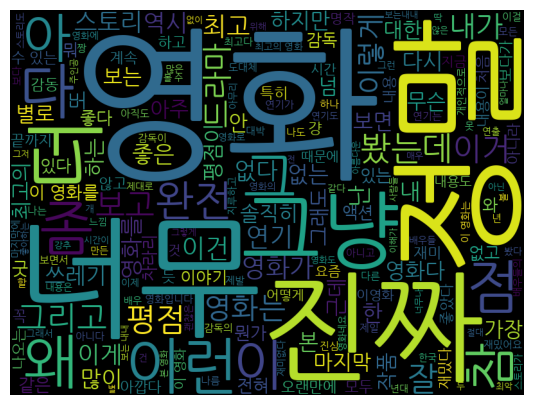

In [ ]:
# 워드 클라우드 시각화
from wordcloud import WordCloud

font_path = '/content/drive/MyDrive/Colab Notebooks/NanumFont/NanumGothic.ttf'
cloud = WordCloud(font_path=font_path, width=800, height=600)\
    .generate(" ".join(train_df['document']))

plt.figure(figsize=(10, 5))
plt.imshow(cloud)
plt.axis('off')

plt.show()

In [ ]:
# 토큰화
okt = Okt()

train_df["document"] = train_df["document"].str.replace(   # 텍스트 정제
    "[^A-Za-z가-힣]", " ", regex=True)

stop_words = ["가", "을", "은", "과", "의", "도",   # 불용어 지정
              "이", "를", "는", "와", "에", "들"]

max_length = 50
pad_token = "<PAD>"
UNK_token = "<UNK>"

def tokenize(text):   # 토큰화 함수 정의
    if not isinstance(text, str):
        return []

    tokens = okt.morphs(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = tokens[: max_length]   # 잘라내기
    if len(tokens) < max_length:   # 패딩
        tokens += [pad_token] * (max_length - len(tokens))
    return tokens

tokenized_texts = [tokenize(t) for t in train_df["document"]]

In [ ]:
# 토큰화 후 상위 데이터 확인
train_df_token = train_df["document"][:10].apply(
    lambda x: " ".join(tokenize(x)))

print(train_df_token)

0    아 더빙 진짜 짜증나네요 목소리 <PAD> <PAD> <PAD> <PAD> <PAD...
1    걍 인피니트 짱 이다 진짜 짱 이다 <PAD> <PAD> <PAD> <PAD> <P...
2    나름 심오한 뜻 있는 듯 그냥 학생 선생 놀아나는 영화 절대 아님 <PAD> <PA...
3    엄포스 위력 다시 한번 깨닫게 해준 적 남 꽃 검사 님 연기 정말 좋았어요 완전 명...
4    단순하면서 은은한 매력 영화 <PAD> <PAD> <PAD> <PAD> <PAD> ...
5    영화 사람 영혼 어루만져 줄 수도 있군요 거친 세 상사 잠시 잊고 동화 같은 영화 ...
6    보는내내 그대로 들어맞는 예측 카리스마 없는 악역 <PAD> <PAD> <PAD> ...
7    아 일본 영화 다 이런 건가 유치하다 <PAD> <PAD> <PAD> <PAD> <...
8    뭐 냐 시작 하고 분만 나왔다 리플릿 사진 보며 불안하더니만 <PAD> <PAD> ...
9    성룡 영화 중 최악 인 듯 <PAD> <PAD> <PAD> <PAD> <PAD> <...
Name: document, dtype: object


In [ ]:
# 어휘 사전 생성
def build_vocab(texts, min_freq=2):
    counter = Counter()   # (단어, 빈도)
    for text in texts:
        counter.update(text)

    vocab = {pad_token: 0, UNK_token: 1}

    for word, freq in sorted(counter.items(), key=lambda x: x[1], reverse=True):
        if freq >= min_freq and word not in vocab:
            vocab[word] = len(vocab)

    return vocab

vocab = build_vocab(tokenized_texts)

print(f"vocab size: {len(vocab)} \n")   # 어휘 사전 크기 확인
print(dict(list(vocab.items())[:20]), "\n")   # 어휘 사전 확인

encoded_text0 = [vocab.get(t, vocab[UNK_token]) for t in tokenized_texts[0]]

print(encoded_text0)   # 텍스트 벡터화 결과 확인

vocab size: 10767 

{'<PAD>': 0, '<UNK>': 1, '영화': 2, '너무': 3, '한': 4, '다': 5, '정말': 6, '만': 7, '적': 8, '으로': 9, '진짜': 10, '로': 11, '점': 12, '에서': 13, '것': 14, '연기': 15, '내': 16, '나': 17, '평점': 18, '최고': 19} 

[35, 528, 10, 4305, 537, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
# 학습 데이터/검증 데이터 분할
train_df, valid_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],  # 레이블 비율 유지
    random_state=7)

train_df = train_df.reset_index(drop=True)   # 인덱스 초기화
valid_df = valid_df.reset_index(drop=True)

In [ ]:
# 데이터셋 정의
class NSMCDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab

    def encode(self, tokens):
        return [self.vocab.get(token, self.vocab[UNK_token]) for token in tokens]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = tokenize(self.texts[idx])
        input_ids = self.encode(tokens)
        return {"input_ids": torch.tensor(input_ids, dtype=torch.long),
                "label": torch.tensor(self.labels[idx], dtype=torch.float)}

In [ ]:
# 데이터셋 생성
train_dataset = NSMCDataset(texts=train_df["document"].tolist(),
                            labels=train_df["label"].tolist(),
                            vocab=vocab)

valid_dataset = NSMCDataset(texts=valid_df["document"].tolist(),
                            labels=valid_df["label"].tolist(),
                            vocab=vocab)

test_dataset = NSMCDataset(texts=test_df["document"].fillna("").tolist(),
                           labels=test_df["label"].fillna(0).tolist(),
                           vocab=vocab)

In [ ]:
# 데이터 로더 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# 모델 생성
class SentimentalLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(input_size=embed_dim,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)   # x(배치 크기, 시퀀스 길이)
        lstm_output, _ = self.lstm(x)   # 출력(배치 크기, 시퀀스 길이, 은닉 상태*2)
        last_hs = lstm_output[:, -1, :]   # 마지막 타임 스텝
        output = self.sigmoid(self.fc(last_hs))
        return output

model = SentimentalLSTM(vocab_size=len(vocab), embed_dim=128,
                        hidden_size=16, num_layers=2).to(device)

In [ ]:
# 모델 구조 확인
print(model)

SentimentalLSTM(
  (embedding): Embedding(10767, 128)
  (lstm): LSTM(128, 16, num_layers=2, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [ ]:
# 하이퍼파라미터 설정
loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# 모델 학습
epochs = 5
train_losses = []
valid_losses = []
train_accs = []
valid_accs = []

for epoch in range(epochs):
    model.train()   # 학습 모드

    train_loss = 0
    correct = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].float().unsqueeze(1).to(device)
        outputs = model(input_ids)   # 출력 계산
        loss = loss_fn(outputs, labels)   # 손실 계산

        optimizer.zero_grad()   # 그레디언트 초기화
        loss.backward()   # 역전파
        optimizer.step()   # 최적화 수행

        train_loss += loss.item() * labels.size(0)
        predict = (outputs > 0.5).int()   # 예측
        correct += (predict == labels).sum().item()   # 정확한 예측

    train_loss /= len(train_loader.dataset)   # 학습 손실
    train_acc = correct / len(train_loader.dataset)   # 학습 정확도

    # 검증
    model.eval()   # 평가 모드

    valid_loss = 0
    correct = 0

    with torch.no_grad():   # 검증할 때에는 자동 미분하지 않음
        for batch in valid_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].float().unsqueeze(1).to(device)

            outputs = model(input_ids)
            loss = loss_fn(outputs, labels)
            valid_loss += loss.item() * labels.size(0)
            predict = (outputs > 0.5).int()   # 예측
            correct += (predict == labels).sum().item()   # 정확한 예측

        valid_loss /= len(valid_loader.dataset)   # 검증 손실
        valid_acc = correct / len(valid_loader.dataset)   # 검증 정확도

    train_losses.append(train_loss)   # 학습 손실 저장(학습 결과 시각화용)
    train_accs.append(train_acc)   # 학습 정확도 저장(학습 결과 시각화용)
    valid_losses.append(valid_loss)   # 검증 손실 저장(학습 결과 시각화용)
    valid_accs.append(valid_acc)   # 검증 정확도 저장(학습 결과 시각화용)

    print(f"Epoch {epoch + 1}/{epochs} \n"
          f" - loss: {train_loss:.4f}  - accuracy: {train_acc:.4f}"
          f" - val_loss: {valid_loss:.4f}  - val_accuracy: {valid_acc:.4f}")

Epoch 1/5 
 - loss: 0.6938  - accuracy: 0.4993 - val_loss: 0.6933  - val_accuracy: 0.5000
Epoch 2/5 
 - loss: 0.6623  - accuracy: 0.5889 - val_loss: 0.6095  - val_accuracy: 0.6757
Epoch 3/5 
 - loss: 0.5030  - accuracy: 0.7604 - val_loss: 0.5454  - val_accuracy: 0.7303
Epoch 4/5 
 - loss: 0.3732  - accuracy: 0.8418 - val_loss: 0.5480  - val_accuracy: 0.7543
Epoch 5/5 
 - loss: 0.2827  - accuracy: 0.8878 - val_loss: 0.5790  - val_accuracy: 0.7553


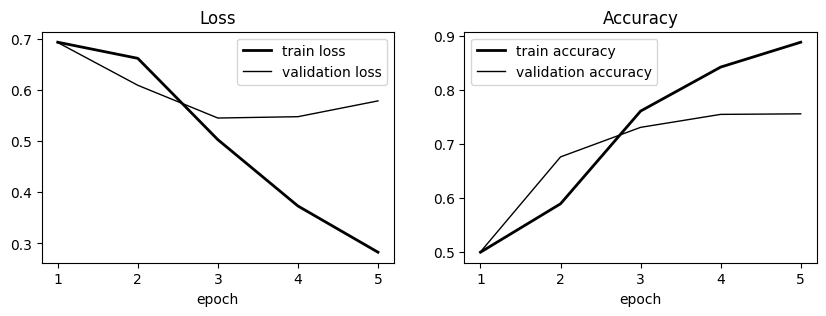

In [ ]:
# 학습 결과 시각화
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label="train loss",
         color='black', linewidth=2)
plt.plot(range(1, epochs + 1), valid_losses, label="validation loss",
         color='black', linewidth=1)
plt.title("Loss")
plt.xlabel("epoch")
plt.legend(loc="best")

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accs, label="train accuracy",
         color='black', linewidth=2)
plt.plot(range(1, epochs + 1), valid_accs, label="validation accuracy",
         color='black', linewidth=1)
plt.title("Accuracy")
plt.xlabel("epoch")
plt.legend(loc="best")

plt.show()

In [ ]:
# 모델 평가
model.eval()   # 평가 모드

correct = 0

with torch.no_grad():   # 평가할 때에는 자동 미분하지 않음
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids)   # 출력 계산
        predict = (outputs > 0.5).squeeze()   # 예측
        correct += (predict == labels).sum().item()   # 정확한 예측

test_acc = 100 * correct / len(test_loader.dataset)   # 정확도 계산

print(f"Accuracy: {test_acc:.2f}%")

Accuracy: 74.52%


In [ ]:
# 모델 예측
model.eval()   # 평가 모드

for batch in test_loader:
    input_ids = batch["input_ids"][:3].to(device)
    labels = batch["label"][:3].to(device)
    break

with torch.no_grad():   # 예측할 때에는 자동 미분하지 않음
    outputs = model(input_ids)
    predict = (outputs >= 0.5).int()   # 예측

for i in range(3):
    print(f"document: {test_df["document"][i]}")
    print(f"label: {int(labels[i].item())}")
    print(f"predict: {predict[i].item()} \n")

document: 굳 ㅋ
label: 1
predict: 1 

document: '13일의 금요일', '나이트메어'시리즈와 함께 가장 많은 시리즈를 양산해냈던 헬레이저 시리즈의 첫편. 작가의 상상력이 돋보이는 작품이며, 갈고리로 사지찢는 고어씬은 지금보더라도 상당히 잔인하고 충격적이다.
label: 1
predict: 1 

document: EBS 한국영화특선 해서 봤다.Biff 개막작 선정되서 왤까 궁금 했었는데 봐도 이율 모르겠다...
label: 0
predict: 0 



In [ ]:
# 예제 7.4 트랜스포머를 이용한 감성 분석

!pip install transformers

In [ ]:
# 감성 분석 파이프라인
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

In [ ]:
# 모델 구조 확인
classifier.model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
# 감성 분석
text1 = "This movie was really fun and exciting. \
         I enjoyed every minute of it."

text2 = "This movie was very boring and too long."

label1, score1 = classifier(text1)[0].values()
label2, score2 = classifier(text2)[0].values()

print(f"text1: {label1.lower()}(score: {score1:.4f})")
print(f"text2: {label2.lower()}(score: {score2:.4f})")

text1: positive(score: 0.9999)
text2: negative(score: 0.9998)


In [ ]:
# 예제 7.5 트랜스포머를 이용한 문장 생성

!pip install transformers

In [ ]:
# 문장 생성 파이프라인
from transformers import pipeline

generator = pipeline("text-generation",
                     model="EleutherAI/polyglot-ko-1.3b",
                     device_map="auto")

In [ ]:
# 모델 구조 확인
generator.model

GPTNeoXForCausalLM(
  (gpt_neox): GPTNeoXModel(
    (embed_in): Embedding(30080, 2048)
    (emb_dropout): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0-23): 24 x GPTNeoXLayer(
        (input_layernorm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
        (post_attention_layernorm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
        (post_attention_dropout): Dropout(p=0.0, inplace=False)
        (post_mlp_dropout): Dropout(p=0.0, inplace=False)
        (attention): GPTNeoXAttention(
          (query_key_value): Linear(in_features=2048, out_features=6144, bias=True)
          (dense): Linear(in_features=2048, out_features=2048, bias=True)
        )
        (mlp): GPTNeoXMLP(
          (dense_h_to_4h): Linear(in_features=2048, out_features=8192, bias=True)
          (dense_4h_to_h): Linear(in_features=8192, out_features=2048, bias=True)
          (act): GELUActivation()
        )
      )
    )
    (final_layer_norm): LayerNorm((2048,), eps=1e-05, 

In [ ]:
# 문장 생성
prompt = "오늘은 날씨가 정말"

generated_text = generator(
    prompt,
    max_new_tokens=100,   # 생성할 최대 토큰 수
    do_sample=True,   # 다음 토큰을 확률적으로 샘플링하여 선택
    temperature=0.8,   # 확률 분포의 랜덤성 조절(작을수록 결정적)
    top_k=50,   # 확률이 높은 상위 k개 토큰만 후보로 사용
    top_p=0.95,   # 누적 확률이 p가 될 때까지의 토큰만 후보로 사용
    repetition_penalty=1.2,   # 이미 생성된 토큰의 확률을 낮춰 반복을 줄임
    num_return_sequences=2   # 생성할 텍스트 수
)

for i, text in enumerate(generated_text):
    print(f"text {i + 1}:")
    print(text["generated_text"], "\n")

Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


text 1:
오늘은 날씨가 정말 좋아서기분이 다 좋았어요~​ ​저희는 오늘도 카페를 찾아왔는데요!여기로 오게 된 이유는~제가 인스타에서 이쁜 감성의카페를 발견했는데,바로 이 곳을 오려고 했던거였죠 ㅎㅎ​ ​그래서 저와 친구들은음료 3잔이랑 디저트 2개를 시켰답니다:)​저랑 제 친구들이시킨 메뉴는요~!초코라떼 4. 

text 2:
오늘은 날씨가 정말 좋았어요~^- ^어제만 해도 바람이 엄청 불어서 벚꽃잎들이 다 날아가서 별로였는데 오늘 아침에는 햇살도 너무 따뜻하고 하늘이 너무 예쁘더라구요. (바람불기전엔 안예뻤음;)벚꽃구경도 많이들 가셨을텐데.....아직 못보신분들 있으면 보러가시라고 포스팅해봅니다! 전 아직 꽃놀이를 한번도 못해봤어요ㅠ_ㅜ작년까지만해도 

